## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
import itertools
import warnings

warnings.filterwarnings("ignore")

## Load Dataset

In [ ]:
df = pd.read_csv("oil_prices_2426.csv")

df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

df.head()

,price (dollars)
date,
2024-09-21,32.10
2024-09-22,32.25
2024-09-23,31.07
2024-09-24,31.50
2024-09-25,32.21


## Exploratory Data Analysis (EDA)

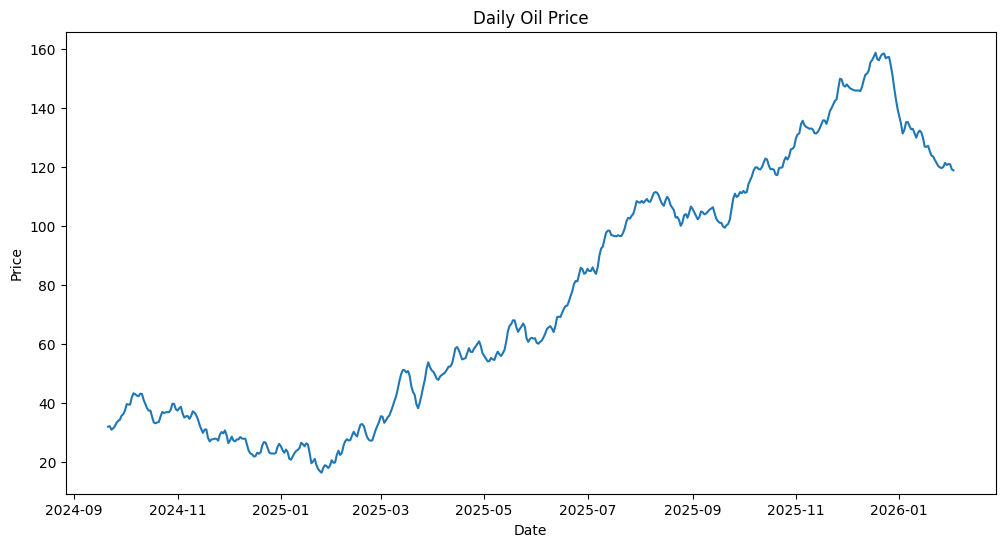

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df['price (dollars)'])
plt.title("Daily Oil Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

## Rolling Mean & Std

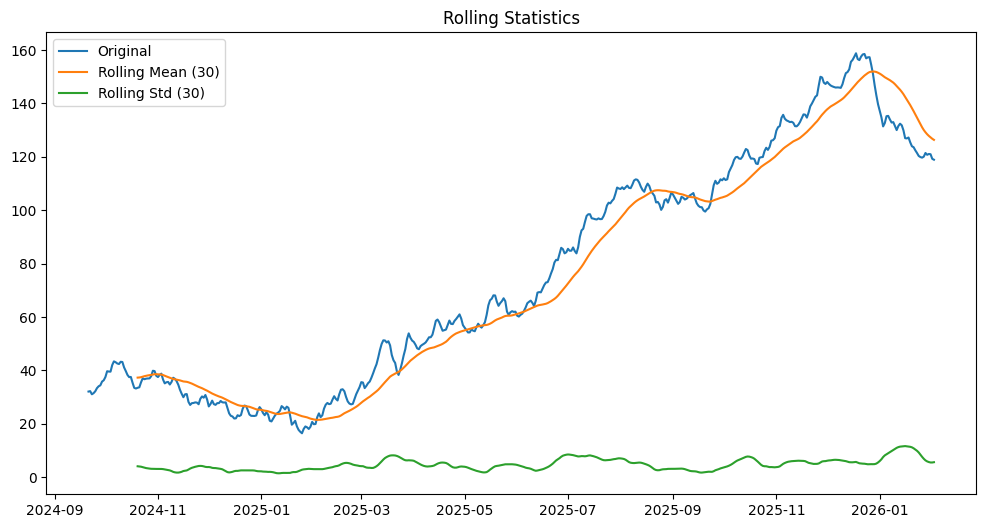

In [ ]:
rolling_mean = df['price (dollars)'].rolling(window=30).mean()
rolling_std = df['price (dollars)'].rolling(window=30).std()

plt.figure(figsize=(12,6))
plt.plot(df['price (dollars)'], label="Original")
plt.plot(rolling_mean, label="Rolling Mean (30)")
plt.plot(rolling_std, label="Rolling Std (30)")
plt.legend()
plt.title("Rolling Statistics")
plt.show()

## Histogram

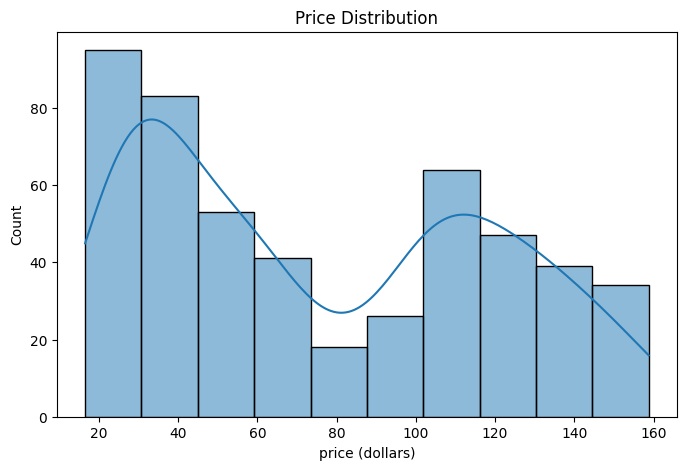

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['price (dollars)'], kde=True)
plt.title("Price Distribution")
plt.show()

## ACF and PACF Plots

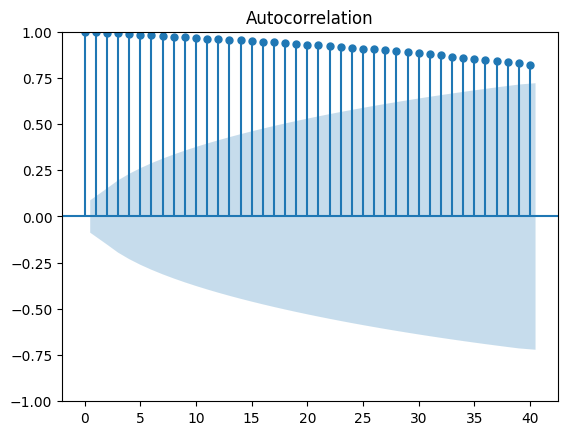

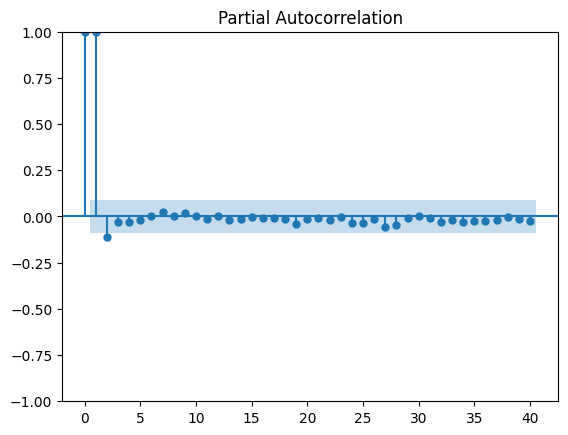

In [ ]:
plot_acf(df['price (dollars)'], lags=40)
plt.show()

plot_pacf(df['price (dollars)'], lags=40)
plt.show()

## Test for Stationarity (ADF Test)

In [ ]:
result = adfuller(df['price (dollars)'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -0.5462340182601634
p-value: 0.8826741397403068


| p-value  | Interpretation |
|----------|---------------|
| p < 0.05 | Stationary |
| p > 0.05 | Non-stationary |

0.882 > 0.05;

The oil price time series is NON-STATIONARY.

## Make Data Stationary

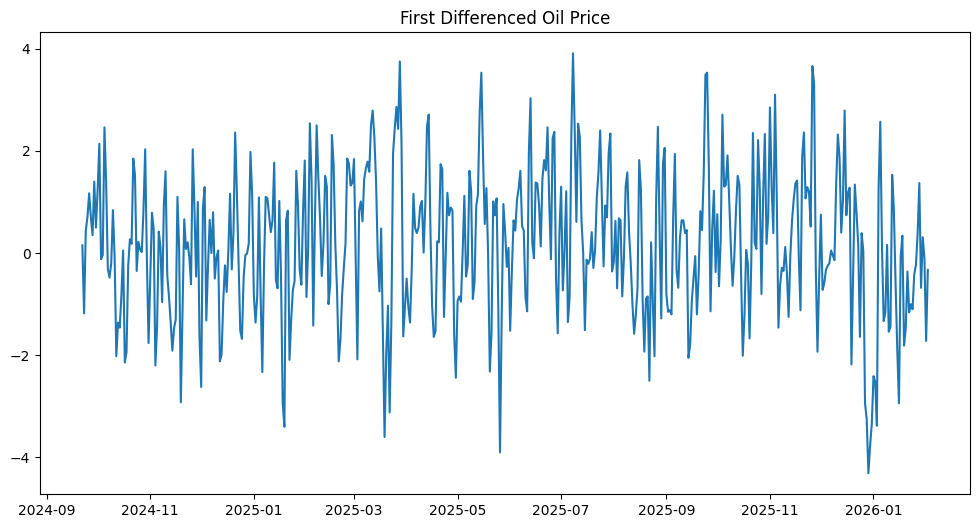

In [ ]:
df_diff = df['price (dollars)'].diff().dropna()

plt.figure(figsize=(12,6))
plt.plot(df_diff)
plt.title("First Differenced Oil Price")
plt.show()

## Run ADF Test Again

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_diff)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -4.541460173486703
p-value: 0.00016536459860957148


In this case:

0.000165 < 0.05


The differenced oil price series is stationary.


## Grid Search Code

In [ ]:
import itertools
import statsmodels.api as sm

p = range(0,9)
d = range(0,3)
q = range(0,9)

pdq = list(itertools.product(p,d,q))

best_aic = float("inf")
best_order = None

for param in pdq:
    try:
        model = sm.tsa.ARIMA(df['price (dollars)'], order=param)
        results = model.fit()

        if results.aic < best_aic:
            best_aic = results.aic
            best_order = param

    except:
        continue

print("Best ARIMA Order:", best_order)
print("Best AIC:", best_aic)

Best ARIMA Order: (2, 2, 7)
Best AIC: 1429.357098586032


## Fit the Final Model

In [ ]:
model = sm.tsa.ARIMA(df['price (dollars)'], order=(2,2,7))
results = model.fit()

print(results.summary())

                               SARIMAX Results                                
Dep. Variable:        price (dollars)   No. Observations:                  500
Model:                 ARIMA(2, 2, 7)   Log Likelihood                -704.679
Date:                Wed, 11 Mar 2026   AIC                           1429.357
Time:                        00:26:20   BIC                           1471.463
Sample:                    09-21-2024   HQIC                          1445.882
                         - 02-02-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.1824      0.032    -36.884      0.000      -1.245      -1.120
ar.L2         -0.9175      0.032    -28.331      0.000      -0.981      -0.854
ma.L1          1.1486      0.339      3.390      0.0

# Residual Diagnostics

## Residual Plot

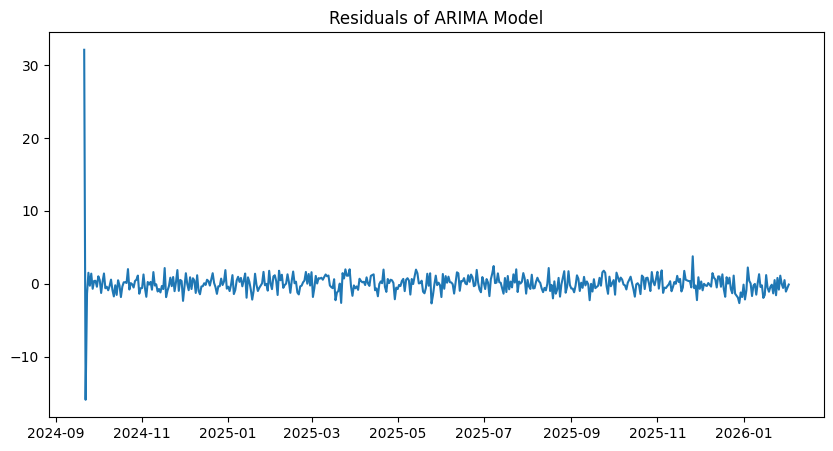

In [ ]:
residuals = results.resid

plt.figure(figsize=(10,5))
plt.plot(residuals)
plt.title("Residuals of ARIMA Model")
plt.show()

## Residual Distribution

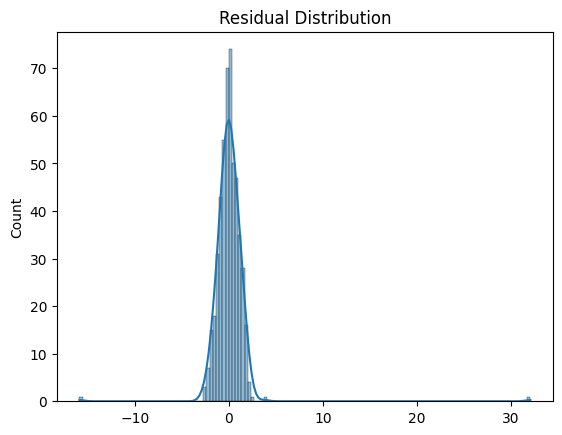

In [ ]:
import seaborn as sns

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

## Residual ACF Plot

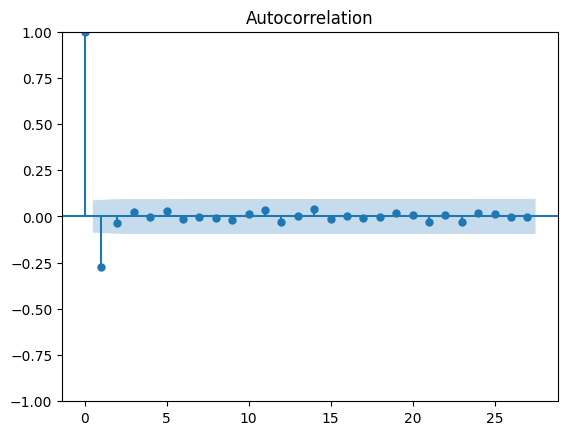

In [ ]:
plot_acf(residuals)
plt.show()

# Model Performance Evaluation (RMSE)

### Split the data first

In [ ]:
train = df['price (dollars)'][:-30]
test = df['price (dollars)'][-30:]

### Fit model again on training set:

In [ ]:
model = sm.tsa.ARIMA(train, order=(2,2,7))
results = model.fit()

forecast = results.forecast(steps=len(test))

### Calculate RMSE:

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, forecast))
print("RMSE:", rmse)

RMSE: 9.434810469813263


### 24 Month Forecast

In [ ]:
forecast_steps = 730

forecast = results.get_forecast(steps=forecast_steps)

forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

### Forecast Plot

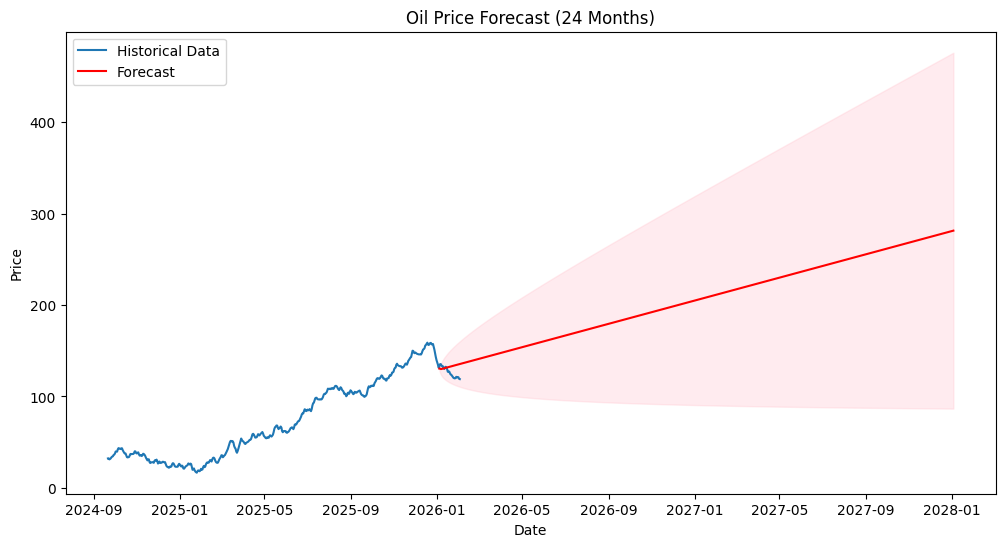

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df['price (dollars)'], label="Historical Data")
plt.plot(forecast_mean, label="Forecast", color="red")

plt.fill_between(
    conf_int.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    color="pink",
    alpha=0.3
)

plt.legend()
plt.title("Oil Price Forecast (24 Months)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

# Part-2

## Implementing an LSTM time-series forecasting model

### Import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

### Prepare Dataset

In [ ]:
data = df['price (dollars)'].values.reshape(-1,1)

print("Original data shape:", data.shape)

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

print("Scaled data shape:", scaled_data.shape)

Original data shape: (500, 1)
Scaled data shape: (500, 1)


### Create Time Sequences

In [ ]:
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):

    X.append(scaled_data[i-sequence_length:i,0])
    y.append(scaled_data[i,0])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (440, 60)
y shape: (440,)


### Reshape Data for LSTM

In [ ]:
X = np.reshape(X, (X.shape[0], X.shape[1], 1))
print("New X shape:", X.shape)

New X shape: (440, 60, 1)


### Train/Test Split

In [ ]:
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (352, 60, 1)
Testing samples: (88, 60, 1)


### Build LSTM Model

In [ ]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(X.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(50))
model.add(Dropout(0.2))

model.add(Dense(1))

### Compile model:

In [ ]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

print("Model built successfully")
model.summary()

Model built successfully


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

### Train Model

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - loss: 0.1085 - val_loss: 0.0299
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0199 - val_loss: 0.0527
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0096 - val_loss: 0.0031
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0045 - val_loss: 0.0039
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0025 - val_loss: 0.0068
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0033 - val_loss: 0.0023
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0025 - val_loss: 0.0029
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0028 - val_loss: 0.0027
Epoch 9/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0025 - val_loss: 0.0032
Epoch 10/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0028 - val_loss: 0.0024
Epoch 11/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0027 - val_loss: 0.0022
Epoch 12/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.

### Model Predictions

In [ ]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step


### Evaluate Model

#### Compute RMSE

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))

print("LSTM RMSE:", rmse)

LSTM RMSE: 7.765653245387958


### Plot Predictions

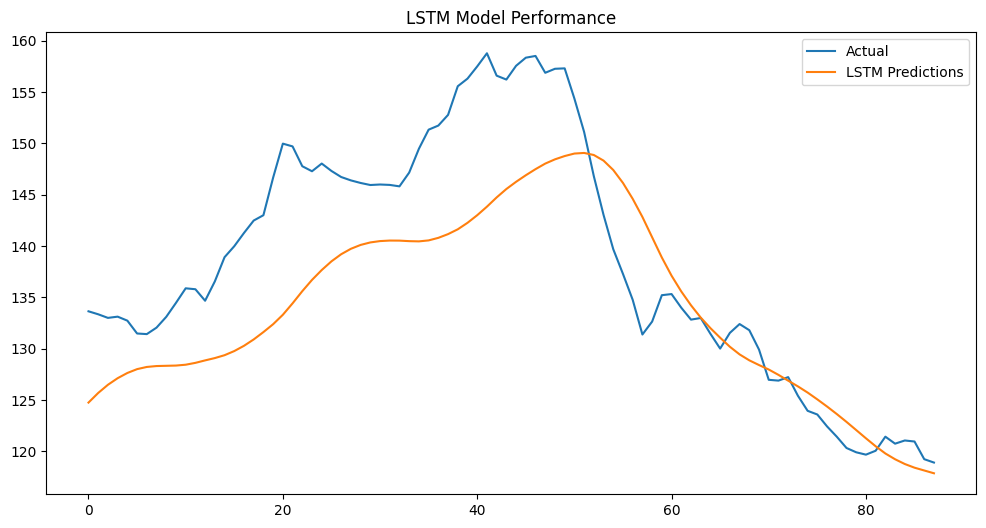

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label="Actual")
plt.plot(predictions, label="LSTM Predictions")

plt.title("LSTM Model Performance")
plt.legend()

plt.show()

### Forecast 24 Months Ahead

In [ ]:
future_steps = 730
last_sequence = scaled_data[-sequence_length:]
future_predictions = []
current_sequence = last_sequence.reshape(1, sequence_length, 1)
for i in range(future_steps):
    next_pred = model.predict(current_sequence, verbose=0)
    future_predictions.append(next_pred[0,0])
    new_value = next_pred.reshape(1,1,1)
    current_sequence = np.concatenate(
        (current_sequence[:,1:,:], new_value),
        axis=1
    )
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

print("Forecast predictions shape:", future_predictions.shape)

Forecast predictions shape: (730, 1)


### Plot LSTM Forecast

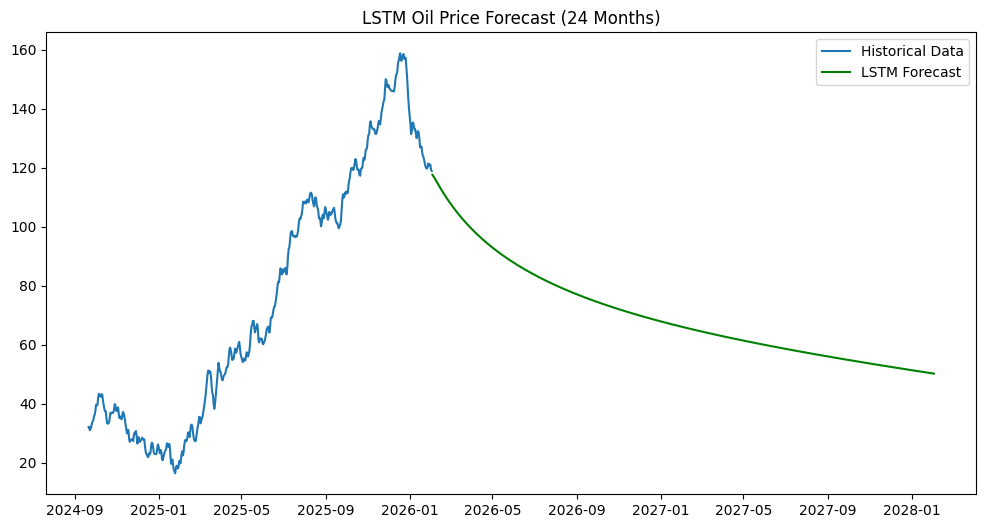

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df['price (dollars)'], label="Historical Data")
future_dates = pd.date_range(
    start=df.index[-1],
    periods=future_steps+1,
    freq='D'
)[1:]

plt.plot(
    future_dates,
    future_predictions,
    label="LSTM Forecast",
    color="green"
)

plt.legend()
plt.title("LSTM Oil Price Forecast (24 Months)")
plt.show()

### Align Test Data for Comparison

In [ ]:
actual = y_test_actual.flatten()
lstm_pred = predictions.flatten()

print("Actual shape:", actual.shape)
print("LSTM shape:", lstm_pred.shape)

Actual shape: (88,)
LSTM shape: (88,)


### ARIMA Predictions on Same Test Window

In [ ]:
arima_model = sm.tsa.ARIMA(train, order=(2,2,7))
arima_results = arima_model.fit()

arima_pred = arima_results.forecast(steps=len(test))

print("ARIMA prediction length:", len(arima_pred))

ARIMA prediction length: 30


In [ ]:
arima_pred = np.array(arima_pred)

### Compute Metrics for Both Models

In [ ]:
from sklearn.metrics import mean_absolute_error

print("Evaluating models...")

arima_rmse = np.sqrt(mean_squared_error(test, arima_pred))
lstm_rmse = np.sqrt(mean_squared_error(actual, lstm_pred))

arima_mae = mean_absolute_error(test, arima_pred)
lstm_mae = mean_absolute_error(actual, lstm_pred)

print("\nModel Performance Comparison")
print("---------------------------")
print("ARIMA RMSE:", arima_rmse)
print("LSTM RMSE:", lstm_rmse)

print("\nARIMA MAE:", arima_mae)
print("LSTM MAE:", lstm_mae)

Evaluating models...

Model Performance Comparison
---------------------------
ARIMA RMSE: 9.434810469813263
LSTM RMSE: 7.765653245387958

ARIMA MAE: 7.737130070522232
LSTM MAE: 6.3961955989490855


### Plot Model Comparison

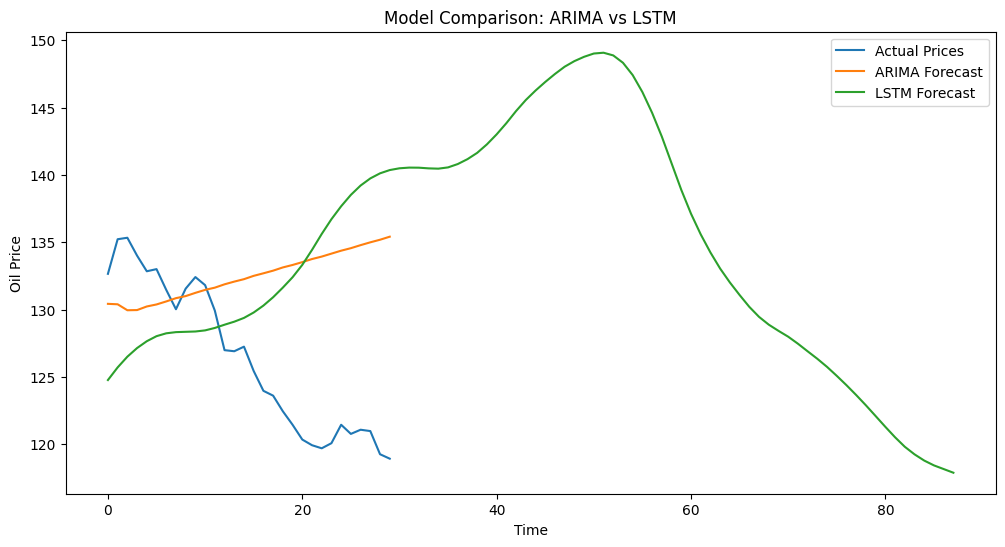

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(test.values, label="Actual Prices")
plt.plot(arima_pred, label="ARIMA Forecast")
plt.plot(lstm_pred, label="LSTM Forecast")

plt.title("Model Comparison: ARIMA vs LSTM")
plt.xlabel("Time")
plt.ylabel("Oil Price")

plt.legend()
plt.show()

### Forecast Comparison (Future)

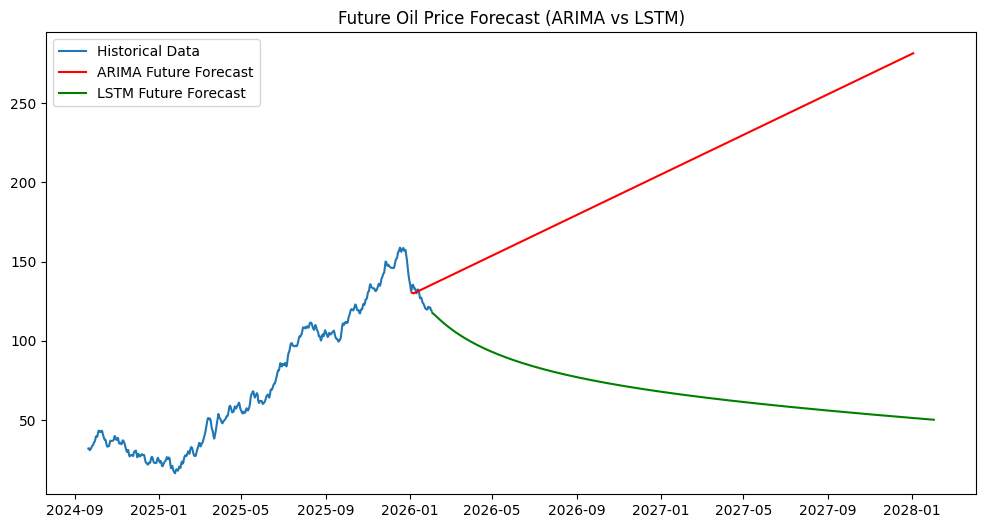

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df['price (dollars)'], label="Historical Data")
plt.plot(forecast_mean, label="ARIMA Future Forecast", color="red")
plt.plot(
    future_dates,
    future_predictions,
    label="LSTM Future Forecast",
    color="green"
)

plt.legend()
plt.title("Future Oil Price Forecast (ARIMA vs LSTM)")
plt.show()